<H1>Task 2: Experimentation and uplift testing</H3>

<p>Building on the first task formulated by the client, the second part extends into experementation. The client has requested an evaluation of a store trial conducted in stores 77, 86, and 88. The desired outcome is to identify the best control stores for each trial store by analyzing pre-trial monthly performance metrics like sales revenue, customer count, and transactions per customer, using a standardized comparison function. Once the optimal control pairs are selected, the analysis must then compare them during the trial period to determine if there was a significant difference in total sales and to identify the underlying driver of any change, such as an increase in customer numbers or purchasing frequency. The initial findings and code are to be submitted as a PDF for review.</p>

In [40]:
#Importing relevant libraries 
import pandas as pd
import numpy as np
from urllib.request import urlretrieve
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import pearsonr, t as t_dist


<H3>Data import and preparation</H3>

This part covers data importing and exploration, including loading the dataset from a URL and performing basic checks on its structure. The reason for importing from URL is because the original dataset couldn't be downloaded into the local environment, so URL was used to fetch it directly. This step ensures that all necessary data is available for analysis.

In [29]:
url = "https://cdn.theforage.com/vinternships/companyassets/32A6DqtsbF7LbKdcq/QVI_data.csv"

data = pd.read_csv(url, sep=',')
print(data.keys())

Index(['LYLTY_CARD_NBR', 'DATE', 'STORE_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND', 'LIFESTAGE',
       'PREMIUM_CUSTOMER'],
      dtype='str')


In [30]:
#After importing the data it's important to make sure that each column is of the correct data type and if there are any missing values
print(data.info())
#There are no missing values in the dataset but date brand, lifestage, premium customer are of the wrong data type
data['DATE'] = pd.to_datetime(data['DATE'])

categorical_cols = ['BRAND', 'LIFESTAGE', 'PREMIUM_CUSTOMER']
for col in categorical_cols:
    data[col] = data[col].astype('category')

#After cleaning the data, it's important to check if there are any duplicate rows
print(data.duplicated().sum())

#Finally I do I final inspection of the data frame to see if everything is in order
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  str    
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  str    
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  str    
 10  LIFESTAGE         264834 non-null  str    
 11  PREMIUM_CUSTOMER  264834 non-null  str    
dtypes: float64(1), int64(6), str(5)
memory usage: 24.2 MB
None
1
<class 'pandas.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  --

After making sure that the data set is whole, I am going to start working through the experimentation task. The client implemented changes in three stores, specifically:
Store <b>77, 86 and 88</b>. They want to know if there was a significant change in sales between these stores compared to the control stores. As a first step I prepare an aggregated dataframe that shows the total sales, total number of customers and average number of transactions per customer for each store and then compare the sales of the three stores

In [31]:
#At first I will create a MONTH_YEAR column which will be useful in aggregating by month and year and store number
data['MONTH_YEAR'] = data['DATE'].dt.to_period('M')

#In this part I will be preforming the aggregation
data_agg = data.groupby(['STORE_NBR', 'MONTH_YEAR']).agg(
    MONTH_SALES = ('TOT_SALES', 'sum'), 
    NUM_CUSTOMERS = ('LYLTY_CARD_NBR', 'nunique'),
    NUM_TXNS = ('TXN_ID', 'nunique'),
    MONTH_QTY = ('PROD_QTY', 'sum'), 
)

data_agg = data_agg.reset_index()

After the aggregation I will derrive additional variables, such as number of transaction per customer, quantity bought per transaction, and price per unit. 

In [32]:
data_agg['TRANS_CUST'] = (data_agg['NUM_TXNS']/data_agg['NUM_CUSTOMERS']).round(1)
data_agg['SALES_CUST'] = (data_agg['MONTH_SALES']/data_agg['NUM_CUSTOMERS']).round(2)


In [33]:
data_agg.info()

<class 'pandas.DataFrame'>
RangeIndex: 3169 entries, 0 to 3168
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype    
---  ------         --------------  -----    
 0   STORE_NBR      3169 non-null   int64    
 1   MONTH_YEAR     3169 non-null   period[M]
 2   MONTH_SALES    3169 non-null   float64  
 3   NUM_CUSTOMERS  3169 non-null   int64    
 4   NUM_TXNS       3169 non-null   int64    
 5   MONTH_QTY      3169 non-null   int64    
 6   TRANS_CUST     3169 non-null   float64  
 7   SALES_CUST     3169 non-null   float64  
dtypes: float64(3), int64(4), period[M](1)
memory usage: 198.2 KB


<H3>Setting up the expriment</H3>

In this part I will set up the expriement, identify the store that are most comparable using the Pearson correlation to identify the most comparable stores. I will also filter for stores that have a whole year of data available.

In [34]:
#This will be useful later
TEST_STORES = [77, 86, 88]
TRIAL_START = pd.Period('2019-02', freq='M')
#Filter to out stores that only have data between June 2018 and July 2019
MONTH_YEAR = data_agg.loc[:, 'MONTH_YEAR']
MONTH_YEAR_FILTER = np.logical_and(MONTH_YEAR >= '2018-06', MONTH_YEAR <= '2019-07')
data_agg_filtered = data_agg[MONTH_YEAR_FILTER]

#Next I will filter for to the stores with observation period of 12 months
store_counts = data_agg_filtered['STORE_NBR'].value_counts()
stores_12_obs = store_counts[store_counts == 12].index
data_final = data_agg[data_agg['STORE_NBR'].isin(stores_12_obs)]

#Some clean up
del store_counts
del stores_12_obs
del data_agg_filtered


After filtering the data, I am going to split into pre-trial and trial-periods and use Pearson's correlation to determine the best comparable stores to the ones on which the trail is being run. 

In [35]:
pre_trial = data_final[data_final['MONTH_YEAR'] < TRIAL_START]

SCORING_METRICS = ["MONTH_SALES", "NUM_CUSTOMERS"]


def make_pivot(df, metric):
    return df.pivot(index="MONTH_YEAR", columns="STORE_NBR", values=metric)


def calculate_correlation(pre_trial_df, trial_store):
    """Returns a Series of average Pearson correlation across scoring metrics."""
    all_corrs = {}
    for metric in SCORING_METRICS:
        pivot = make_pivot(pre_trial_df, metric)
        candidates = [s for s in pivot.columns if s not in TEST_STORES]
        trial_series = pivot[trial_store].dropna()
        corrs = {}
        for store in candidates:
            ctrl = pivot[store].dropna()
            shared = trial_series.index.intersection(ctrl.index)
            if len(shared) < 3:
                continue
            corr, _ = pearsonr(trial_series[shared], ctrl[shared])
            corrs[store] = corr
        all_corrs[metric] = pd.Series(corrs)
    return pd.DataFrame(all_corrs).mean(axis=1)  # avg across metrics


def calculate_magnitude(pre_trial_df, trial_store):
    """
    Returns a Series of average standardised magnitude distance (0–1, higher = closer)
    across scoring metrics.
    """
    all_mag = {}
    for metric in SCORING_METRICS:
        pivot = make_pivot(pre_trial_df, metric)
        candidates = [s for s in pivot.columns if s not in TEST_STORES]
        trial_series = pivot[trial_store].dropna()
        abs_diffs = {}
        for store in candidates:
            ctrl = pivot[store].dropna()
            shared = trial_series.index.intersection(ctrl.index)
            if len(shared) < 3:
                continue
            abs_diffs[store] = np.abs(trial_series[shared] - ctrl[shared]).mean()
        s = pd.Series(abs_diffs)
        # Standardise so that 1 = smallest distance (most similar)
        s_std = 1 - (s - s.min()) / (s.max() - s.min())
        all_mag[metric] = s_std
    return pd.DataFrame(all_mag).mean(axis=1)


def score_control_stores(pre_trial_df, trial_store, corr_weight=0.5):
    corr = calculate_correlation(pre_trial_df, trial_store)
    mag = calculate_magnitude(pre_trial_df, trial_store)
    # Align on common stores
    common = corr.index.intersection(mag.index)
    composite = corr[common] * corr_weight + mag[common] * (1 - corr_weight)
    return composite.sort_values(ascending=False)


# Run for each trial store
best_controls = {}
for store in TEST_STORES:
    scores = score_control_stores(pre_trial, store)
    best = scores.index[0]  # top-ranked store (excluding trial stores already filtered)
    best_controls[store] = best
    print(
        f"Trial store {store} best control: store {best} (composite score: {scores.iloc[0]:.4f})"
    )

Trial store 77 best control: store 233 (composite score: 0.9735)
Trial store 86 best control: store 155 (composite score: 0.9549)
Trial store 88 best control: store 237 (composite score: 0.8140)


Based Pearsons correlation analysis, I was able to identify the following benchmark stores for the chosen stores:
<ul>
<li><b>Trial store 77</b>: store 233</li>
<li><b>Trial store 86</b>: store 155</li>
<li><b>Trial store 88</b>: store 237</li>
</ul>

In the next part I will preform sclaing to ensure the control and trial stores are comparable, plot the trial bs scaled control and preform significance testing using a t-test.

In [36]:
def scale_control(pre_trial_df, full_df, trial_store, control_store, metric):
    trial_pre_mean = pre_trial_df[pre_trial_df["STORE_NBR"] == trial_store][metric].mean()
    control_pre_mean = pre_trial_df[pre_trial_df["STORE_NBR"] == control_store][metric].mean()

    scale_factor = trial_pre_mean / control_pre_mean

    trial_s = full_df[full_df["STORE_NBR"] == trial_store][["MONTH_YEAR", metric]].set_index("MONTH_YEAR")[metric]
    control_s = full_df[full_df["STORE_NBR"] == control_store][["MONTH_YEAR", metric]].set_index("MONTH_YEAR")[metric]
    
    return trial_s, control_s * scale_factor, scale_factor

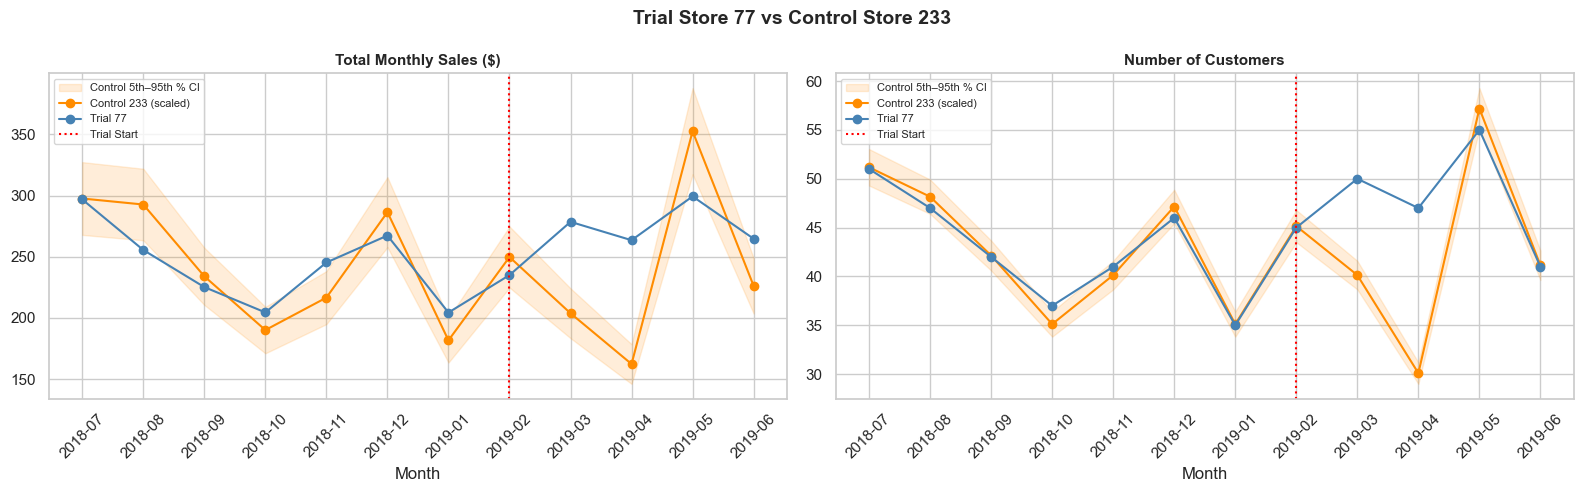

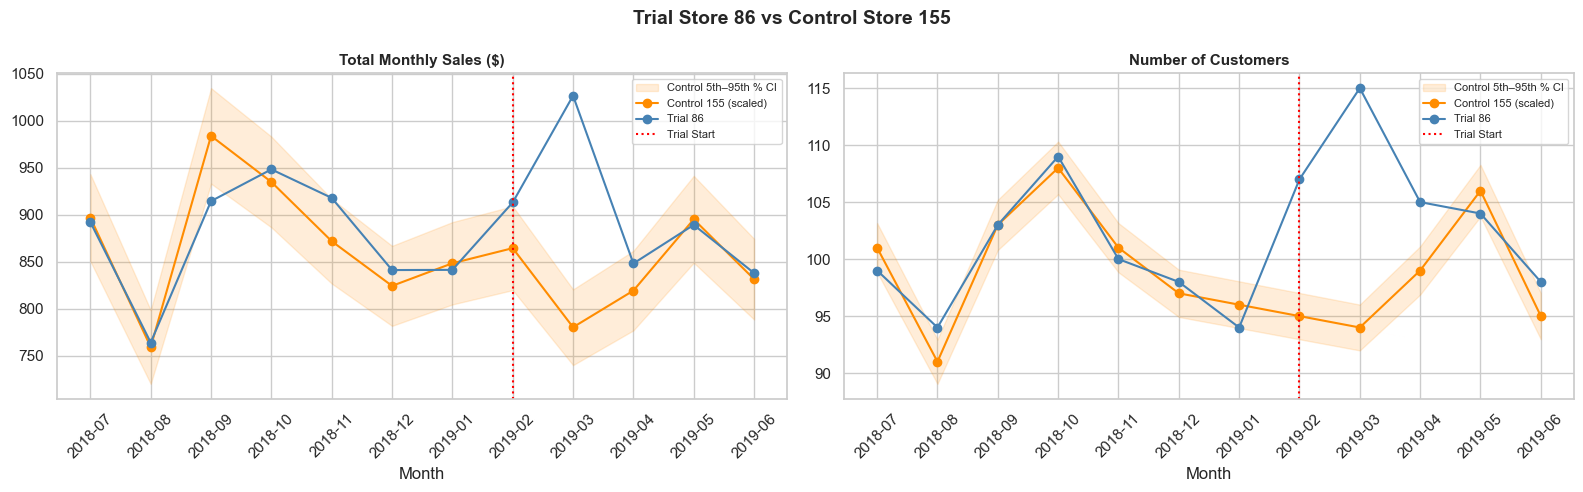

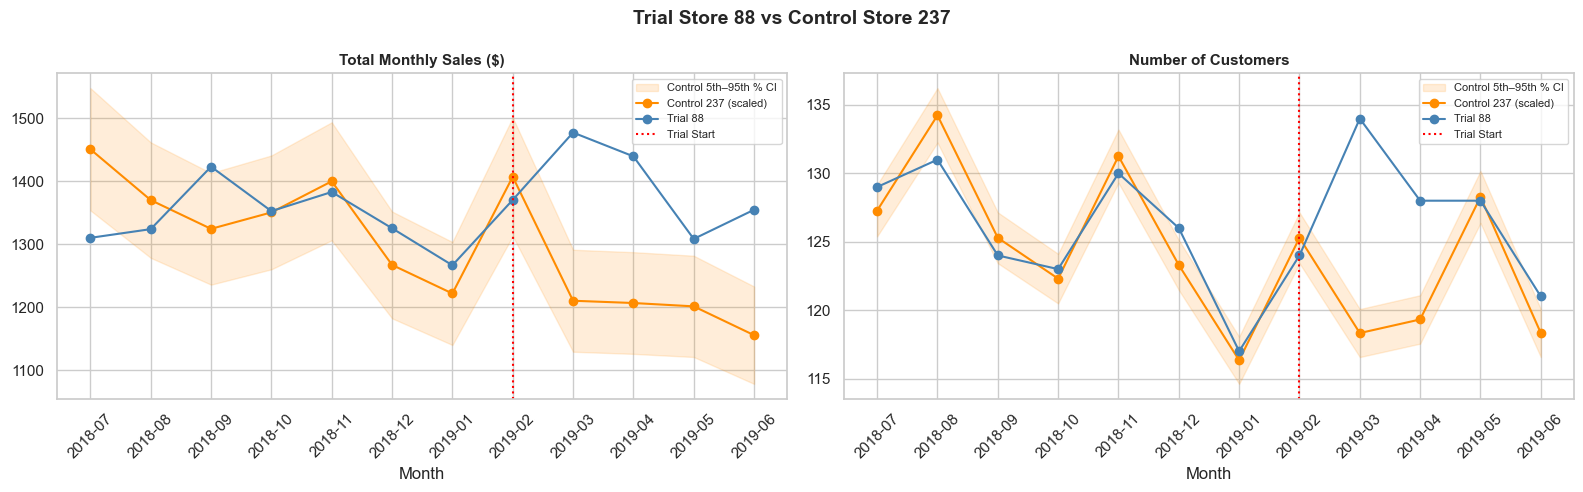

In [38]:
# Plotting
METRICS = {
    "MONTH_SALES": "Total Monthly Sales ($)",
    "NUM_CUSTOMERS": "Number of Customers",
    "TRANS_CUST": "Avg Transactions per Customer",
}


def plot_trial_vs_control_v2(full_df, pre_trial_df, trial_store, control_store):
    sns.set_theme(style="whitegrid", palette="muted")
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(
        f"Trial Store {trial_store} vs Control Store {control_store}",
        fontsize=14,
        fontweight="bold",
    )

    for ax, (metric, label) in zip(axes, METRICS.items()):
        trial_s, scaled_ctrl, _ = scale_control(
            pre_trial_df, full_df, trial_store, control_store, metric
        )
        pct_diff = np.abs(trial_s - scaled_ctrl) / scaled_ctrl
        pre_pct = pct_diff[pct_diff.index < TRIAL_START]
        std_dev = pre_pct.std()

        months = [str(m) for m in trial_s.index]
        trial_vals = trial_s.values
        ctrl_vals = scaled_ctrl.reindex(trial_s.index).values
        upper = ctrl_vals * (1 + std_dev * 2)
        lower = ctrl_vals * (1 - std_dev * 2)

        ax.fill_between(
            months,
            lower,
            upper,
            alpha=0.15,
            color="darkorange",
            label="Control 5th–95th % CI",
        )
        ax.plot(
            months,
            ctrl_vals,
            color="darkorange",
            marker="o",
            label=f"Control {control_store} (scaled)",
        )
        ax.plot(
            months,
            trial_vals,
            color="steelblue",
            marker="o",
            label=f"Trial {trial_store}",
        )

        # Trial start marker
        trial_start_str = str(TRIAL_START)
        if trial_start_str in months:
            ax.axvline(
                x=trial_start_str,
                color="red",
                linestyle=":",
                linewidth=1.5,
                label="Trial Start",
            )

        ax.set_title(label, fontsize=11, fontweight="bold")
        ax.set_xlabel("Month")
        ax.tick_params(axis="x", rotation=45)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


for trial_store, control_store in best_controls.items():
    plot_trial_vs_control_v2(data_final, pre_trial, trial_store, control_store)

In [41]:
# Testing the significance
DEGREES_OF_FREEDOM = 7  # 8 pre-trial months − 1
T_CRIT = t_dist.ppf(0.95, df=DEGREES_OF_FREEDOM)
TRIAL_MONTHS = [m for m in data_final["MONTH_YEAR"].unique() if m >= TRIAL_START]

METRICS = {
    "MONTH_SALES": "Total Monthly Sales ($)",
    "NUM_CUSTOMERS": "Number of Customers",
}


def test_significance_v2(full_df, pre_trial_df, trial_store, control_store):
    print(f"\n{'='*60}")
    print(f"  Trial Store {trial_store} vs Control Store {control_store}")
    print(f"{'='*60}")

    for metric, label in METRICS.items():
        trial_s, scaled_ctrl, _ = scale_control(
            pre_trial_df, full_df, trial_store, control_store, metric
        )
        # Percentage difference series (absolute)
        pct_diff = np.abs(trial_s - scaled_ctrl) / scaled_ctrl

        # Std dev from pre-trial months only
        pre_pct = pct_diff[pct_diff.index < TRIAL_START]
        std_dev = pre_pct.std()

        # t-values for trial months
        trial_pct = pct_diff[pct_diff.index >= TRIAL_START]
        t_values = trial_pct / std_dev

        significant_months = (t_values > T_CRIT).sum()

        print(f"\n  {label}")
        print(f"  Pre-trial std dev of % diff : {std_dev:.4f}")
        print(f"  t-critical (95%, df=7)      : {T_CRIT:.4f}")
        for month, tv in t_values.items():
            sig = "significant" if tv > T_CRIT else "not significant"
            print(f"{month}  t = {tv:.3f}  {sig}")
        print(f"Significant in {significant_months}/3 trial months")


for trial_store, control_store in best_controls.items():
    test_significance_v2(data_final, pre_trial, trial_store, control_store)


  Trial Store 77 vs Control Store 233

  Total Monthly Sales ($)
  Pre-trial std dev of % diff : 0.0499
  t-critical (95%, df=7)      : 1.8946
2019-02  t = 1.184  not significant
2019-03  t = 7.339  significant
2019-04  t = 12.476  significant
2019-05  t = 3.024  significant
2019-06  t = 3.406  significant
Significant in 4/3 trial months

  Number of Customers
  Pre-trial std dev of % diff : 0.0182
  t-critical (95%, df=7)      : 1.8946
2019-02  t = 0.183  not significant
2019-03  t = 13.476  significant
2019-04  t = 30.779  significant
2019-05  t = 2.101  significant
2019-06  t = 0.183  not significant
Significant in 3/3 trial months

  Trial Store 86 vs Control Store 155

  Total Monthly Sales ($)
  Pre-trial std dev of % diff : 0.0258
  t-critical (95%, df=7)      : 1.8946
2019-02  t = 2.180  significant
2019-03  t = 12.227  significant
2019-04  t = 1.365  not significant
2019-05  t = 0.256  not significant
2019-06  t = 0.301  not significant
Significant in 2/3 trial months

  Numb

All three trial stores show statistically significant effects, though the nature of the uplift differs across stores.

Store 77 (control: 233) is a clear success. Sales broke outside the control confidence interval in 3 of the trial months, driven by a significant increase in customer numbers across the same period. This suggests the trial was effective at attracting new buyers rather than changing existing purchase behaviour.

Store 88 (control: 237) shows a similarly strong result. Sales were significant in 4 trial months and customer numbers in 3, indicating a genuine positive trial effect comparable in strength to store 77.

Store 86 (control: 155) presents a more nuanced picture. Customer numbers were significantly higher across most trial months, yet sales significance was
limited to the first two months. This divergence: more customers but not proportionally higher sales — may indicate that promotional pricing or discounting during the trial dampened the revenue impact. This warrants a follow-up with the Category Manager to confirm whether special deals were running in store 86 during the trial period.

Overall, the trial shows a meaningful positive effect across all three stores. Stores 77 and 88 provide a compelling case for broader rollout. Store 86 requires further investigation before the same conclusion can be drawn, but the customer uplift there is encouraging.